# Processamento de Sinais I — Aula Prática 2
## Questão 9 — Espectro de `h_banheiro.wav` e `sinal_taca.wav`

Objetivo: calcular o espectro dos dois sinais e comentar os resultados.

## Importar bibliotecas e carregar a função de espectro

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy import signal

def load_calculate_spectrum():
    notebook_path = Path('../tools/calculate_spectrum.ipynb')
    notebook = json.loads(notebook_path.read_text(encoding='utf-8'))

    namespace = {}
    for cell in notebook['cells']:
        if cell.get('cell_type') != 'code':
            continue

        source = ''.join(cell.get('source', []))
        exec(source, namespace)
        if 'calculate_spectrum' in namespace:
            return namespace['calculate_spectrum']

    raise RuntimeError('calculate_spectrum() nao encontrada em ../tools/calculate_spectrum.ipynb')

calculate_spectrum = load_calculate_spectrum()

plt.style.use('seaborn-v0_8-whitegrid')

def to_float_mono(data):
    data = np.asarray(data)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float64) / np.iinfo(data.dtype).max
    else:
        data = data.astype(np.float64)
    peak = np.max(np.abs(data))
    if peak > 1:
        data = data / peak
    return data


def show_audio(audio, rate, label):
    print(label)
    display(Audio(audio, rate=rate))


def plot_spectrum(signal_in, sampling_frequency, title, max_frequency=None):
    freqs, amps = calculate_spectrum(signal_in, sampling_frequency, single_sided=True)
    plt.figure(figsize=(12, 4))
    plt.plot(freqs, amps)
    if max_frequency is not None:
        plt.xlim(0, max_frequency)
    plt.title(title)
    plt.xlabel('Frequencia (Hz)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    return freqs, amps


## Ler os sinais, visualizar tempo e espectro, e ouvir

Audio: Resposta ao impulso do banheiro


Audio: Sinal da taca


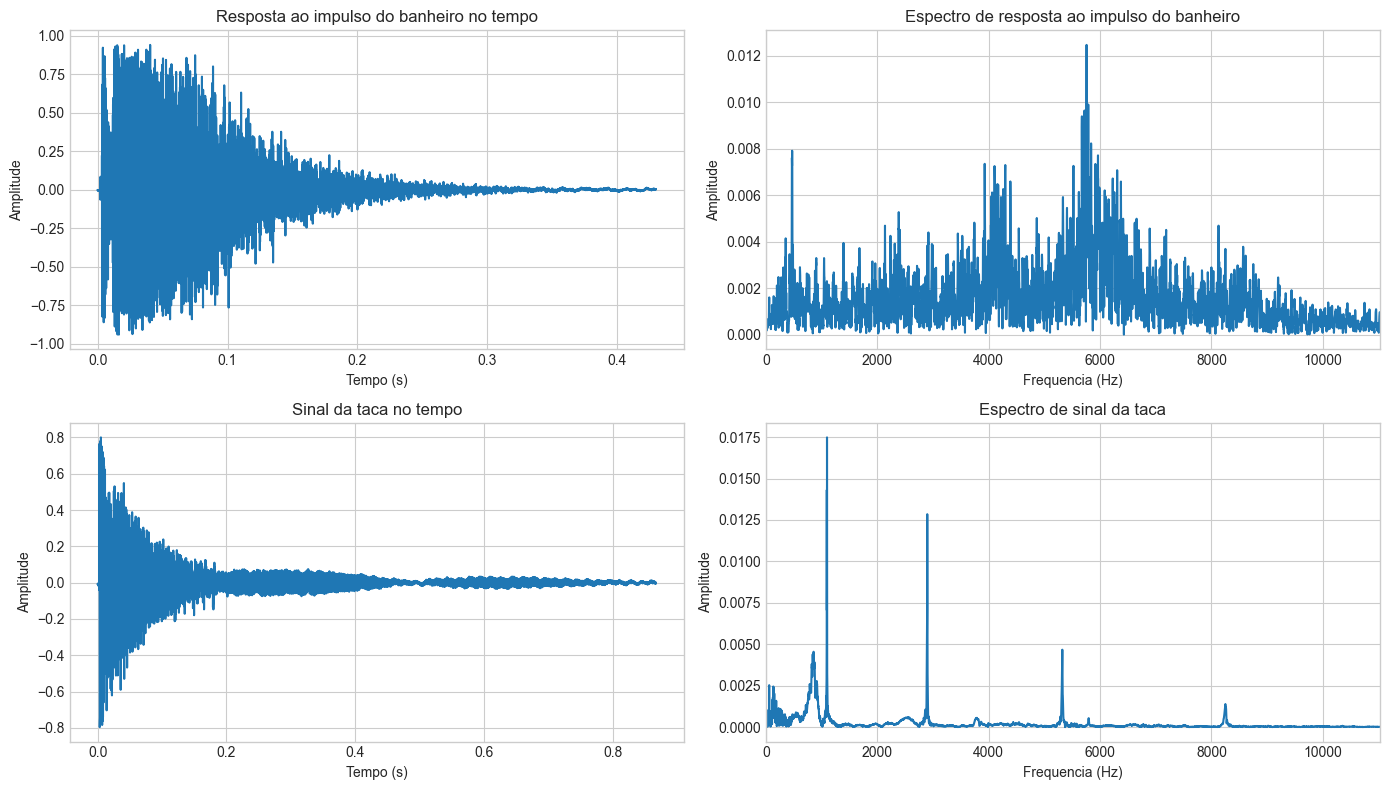

In [2]:
arquivos = {
    'Resposta ao impulso do banheiro': '../data/h_banheiro.wav',
    'Sinal da taca': '../data/sinal_taca.wav',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (nome, caminho) in enumerate(arquivos.items()):
    fs, audio_int = wavfile.read(caminho)
    audio = to_float_mono(audio_int)
    tempo = np.arange(len(audio)) / fs

    axes[i, 0].plot(tempo, audio)
    axes[i, 0].set_title(f'{nome} no tempo')
    axes[i, 0].set_xlabel('Tempo (s)')
    axes[i, 0].set_ylabel('Amplitude')

    freqs, amps = calculate_spectrum(audio, fs, single_sided=True)
    axes[i, 1].plot(freqs, amps)
    axes[i, 1].set_xlim(0, fs / 2)
    axes[i, 1].set_title(f'Espectro de {nome.lower()}')
    axes[i, 1].set_xlabel('Frequencia (Hz)')
    axes[i, 1].set_ylabel('Amplitude')

    show_audio(audio, fs, f'Audio: {nome}')

plt.tight_layout()


## Comentários

`h_banheiro.wav` apresenta o comportamento típico de uma resposta ao impulso: um evento curto com energia distribuída em ampla faixa de frequência e decaimento temporal associado às reflexões do ambiente.

`sinal_taca.wav` mostra um conteúdo mais ressonante, com componentes concentradas em frequências específicas. Isso é coerente com o som de uma taça, que tende a vibrar em modos preferenciais após o impacto.